# 04 - Danh gia he thong (FAR/FRR + WIDER FACE + MOT17)

**3 phan doc lap, chay duoc rieng le:**
- **Phan A** - FAR/FRR/EER cho face recognition (bao gom phan test "nguoi la" con thieu tu Notebook 02). Khong can tai gi them, dung lai du lieu co san.
- **Phan B** - Danh gia face detection tren **WIDER FACE** (validation split, tai qua thu vien `datasets` cua HuggingFace, khong can tai file zip thu cong).
- **Phan C** - Danh gia tracking tren **MOT17** (can tai thu cong tu motchallenge.net, khong co API tu dong).

Neu Phan B hoac C chua co du lieu, notebook se in huong dan va **bo qua phan do**, khong crash toan bo notebook - ban co the chay rieng Phan A truoc, roi quay lai B/C sau khi co du lieu.

In [1]:
# ===== CELL 1: Thiet lap duong dan & load gallery =====
import os
import json
import pickle

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r'D:\face-security-system'
AI_DIR = os.path.join(BASE_DIR, 'ai')

SPLIT_GALLERY   = os.path.join(AI_DIR, 'dataset', 'splits', 'gallery')
SPLIT_PROBE     = os.path.join(AI_DIR, 'dataset', 'splits', 'probe')
PROCESSED_DIR   = os.path.join(AI_DIR, 'dataset', 'processed', 'gallery')
MODELS_DIR      = os.path.join(AI_DIR, 'models')
BENCHMARK_DIR   = os.path.join(AI_DIR, 'dataset', 'benchmarks')
RESULTS_DIR     = os.path.join(AI_DIR, 'dataset', 'evaluation_results')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(BENCHMARK_DIR, 'mot17'), exist_ok=True)

gallery_path = os.path.join(MODELS_DIR, 'gallery_embeddings.pkl')
assert os.path.exists(gallery_path), "Chua co gallery_embeddings.pkl - chay xong Notebook 02 truoc"

with open(gallery_path, 'rb') as f:
    gallery = pickle.load(f)

print(f"Da load gallery: {len(gallery)} nguoi da enroll")
print(f"RESULTS_DIR = {RESULTS_DIR}")


Da load gallery: 65 nguoi da enroll
RESULTS_DIR = D:\face-security-system\ai\dataset\evaluation_results


In [2]:
# ===== CELL 2: Cai dat thu vien rieng cho notebook nay =====
# ultralytics, insightface, onnxruntime, opencv, sklearn... da co tu Notebook 01/02.
# datasets (HuggingFace, cho WIDER FACE) va motmetrics (cho MOT17) la moi.
!pip install -q datasets motmetrics

print("Da cai/kiem tra: datasets, motmetrics")


Da cai/kiem tra: datasets, motmetrics



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ===== CELL 3: Khoi tao lai face_app + get_embedding (GPU/CUDA) =====
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import torch
import onnxruntime as ort
from insightface.app import FaceAnalysis

print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("ONNX Runtime version:", ort.__version__)
print("Available ORT providers:", ort.get_available_providers())

if "CUDAExecutionProvider" not in ort.get_available_providers():
    raise RuntimeError("CUDAExecutionProvider khong kha dung. Hay kiem tra lai moi truong CUDA/cuDNN/onnxruntime-gpu.")

face_app = FaceAnalysis(
    name="buffalo_l",
    allowed_modules=["detection", "recognition"],
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
)
face_app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)

actual_det_providers = face_app.models["detection"].session.get_providers()
print("Detection providers:", actual_det_providers)
if "CUDAExecutionProvider" not in actual_det_providers:
    raise RuntimeError("FaceAnalysis detector van chay CPU, khong phai GPU.")

PAD_RATIO = 0.4


def get_embedding(img_bgr, pad_ratio=PAD_RATIO):
    """Dung cho anh CROP SAT (gallery/probe 112x112, nguoi cat tu YOLOv8) - co padding."""
    if img_bgr is None or img_bgr.size == 0:
        return None, None
    h, w = img_bgr.shape[:2]
    pad_h, pad_w = int(h * pad_ratio), int(w * pad_ratio)
    padded = cv2.copyMakeBorder(img_bgr, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT)
    faces = face_app.get(padded)
    if not faces:
        return None, None
    best = max(faces, key=lambda f: f.det_score)
    emb = best.embedding.astype(np.float32)
    emb = emb / (np.linalg.norm(emb) + 1e-10)
    return emb, float(best.det_score)


def match_against_gallery(emb, gallery_dict):
    """Tra ve (best_person, best_score) KHONG ap threshold - dung rieng cho danh gia,
    de co the sweep threshold sau ma khong phai chay lai detection."""
    if emb is None or not gallery_dict:
        return None, -1.0
    best_person, best_score = None, -1.0
    for person, gemb in gallery_dict.items():
        score = float(np.dot(emb, gemb))
        if score > best_score:
            best_person, best_score = person, score
    return best_person, best_score

print("Da khoi tao face_app va dinh nghia get_embedding() / match_against_gallery()")


d:\face-security-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 5070
ONNX Runtime version: 1.26.0
Available ORT providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvi

## PHAN A - FAR / FRR / EER cho Face Recognition

- **Genuine (probe)**: anh cua nguoi DA co trong gallery -> do FRR (bi tu choi nham)
- **Impostor (nguoi la that su)**: lay THEM mot batch LFW khac (nhung nguoi it anh, chua tung
  duoc dua vao gallery o Notebook 01 vi `min_faces_per_person=20` da loai ho tu dau) -> do FAR
  (bi nhan nham la nguoi quen)

Sweep qua nhieu threshold thay vi chi 1 gia tri co dinh, de tim **Equal Error Rate (EER)** -
diem ma FAR va FRR gan bang nhau, la thuoc tinh chuan de bao cao trong he thong sinh trac hoc.

In [4]:
# ===== CELL 4: Tinh diem genuine (Probe set - nguoi DA co trong gallery) =====

genuine_rows = []
for person in sorted(os.listdir(SPLIT_PROBE)):
    person_dir = os.path.join(SPLIT_PROBE, person)
    for fname in os.listdir(person_dir):
        img = cv2.imread(os.path.join(person_dir, fname))
        emb, det_score = get_embedding(img)
        best_person, best_score = match_against_gallery(emb, gallery)
        genuine_rows.append([person, fname, best_person, best_score])

genuine_df = pd.DataFrame(genuine_rows, columns=['true_person', 'filename', 'best_match', 'best_score'])
print(f"So anh genuine (probe): {len(genuine_df)}")
genuine_df.head()


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


So anh genuine (probe): 3390


,true_person,filename,best_match,best_score
0,Alejandro_Toledo,img_000.jpg,Alejandro_Toledo,0.783727
1,Alejandro_Toledo,img_004.jpg,Alejandro_Toledo,0.851483
2,Alejandro_Toledo,img_005.jpg,Alejandro_Toledo,0.843468
3,Alejandro_Toledo,img_007.jpg,Alejandro_Toledo,0.829651
4,Alejandro_Toledo,img_010.jpg,Alejandro_Toledo,0.846581


In [5]:
# ===== CELL 5: Tinh diem impostor (nguoi la that su - LAY THEM tu LFW, khong dung lai probe) =====
from sklearn.datasets import fetch_lfw_people

print("Dang tai/doc cache LFW voi min_faces_per_person=1 (moi nguoi, ke ca it anh)...")
lfw_all = fetch_lfw_people(min_faces_per_person=1, resize=1.0, color=True, download_if_missing=True)

enrolled_people = set(gallery.keys())
stranger_name_set = {n for n in lfw_all.target_names if n.replace(' ', '_') not in enrolled_people}
print(f"So nguoi KHONG co trong gallery (dung lam 'nguoi la'): {len(stranger_name_set)}")

MAX_STRANGER_IMAGES = 500  # gioi han de khong chay qua lau, tang neu muon test ky hon

impostor_rows = []
count = 0
for idx in range(lfw_all.images.shape[0]):
    if count >= MAX_STRANGER_IMAGES:
        break

    person_name = lfw_all.target_names[lfw_all.target[idx]]
    if person_name not in stranger_name_set:
        continue

    img_uint8 = np.clip(lfw_all.images[idx] * 255.0, 0, 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

    emb, det_score = get_embedding(img_bgr)
    if emb is None:
        continue

    best_person, best_score = match_against_gallery(emb, gallery)
    impostor_rows.append([person_name, best_person, best_score])
    count += 1

impostor_df = pd.DataFrame(impostor_rows, columns=['true_person_la', 'best_match', 'best_score'])
print(f"So anh nguoi la da test: {len(impostor_df)}")
impostor_df.head()


Dang tai/doc cache LFW voi min_faces_per_person=1 (moi nguoi, ke ca it anh)...
So nguoi KHONG co trong gallery (dung lam 'nguoi la'): 5687


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


So anh nguoi la da test: 500


,true_person_la,best_match,best_score
0,Tim Curry,Hans_Blix,0.157280
1,Michel Charles Chretien,Alejandro_Toledo,0.136309
2,Abid Hamid Mahmud Al-Tikriti,Saddam_Hussein,0.147377
3,Mona Locke,Bui_Manh_Khoi,0.150240
4,Barbara Bodine,Tom_Ridge,0.141893


In [6]:
# ===== CELL 6: Sweep threshold -> FAR / FRR / EER =====

genuine_valid = genuine_df.dropna(subset=['best_score'])
impostor_valid = impostor_df.dropna(subset=['best_score'])

thresholds = np.arange(0.0, 1.01, 0.02)
far_list, frr_list = [], []

for th in thresholds:
    frr = (
        (genuine_valid['best_score'] < th) |
        ((genuine_valid['best_score'] >= th) & (genuine_valid['best_match'] != genuine_valid['true_person']))
    ).mean()
    far = (impostor_valid['best_score'] >= th).mean()
    far_list.append(far)
    frr_list.append(frr)

roc_df = pd.DataFrame({'threshold': thresholds, 'FAR': far_list, 'FRR': frr_list})
roc_df['diff'] = (roc_df['FAR'] - roc_df['FRR']).abs()
eer_row = roc_df.loc[roc_df['diff'].idxmin()]

current_row = roc_df.iloc[(roc_df['threshold'] - 0.35).abs().argmin()]

print(f"Tai threshold HIEN TAI (0.35): FAR={current_row['FAR']*100:.2f}%  FRR={current_row['FRR']*100:.2f}%")
print(f"Equal Error Rate (EER) tai threshold={eer_row['threshold']:.2f}: FAR={eer_row['FAR']*100:.2f}%  FRR={eer_row['FRR']*100:.2f}%")

roc_csv_path = os.path.join(RESULTS_DIR, 'far_frr_by_threshold.csv')
roc_df.to_csv(roc_csv_path, index=False)
print(f"\nLuu bang FAR/FRR tai: {roc_csv_path}")


Tai threshold HIEN TAI (0.35): FAR=0.20%  FRR=0.29%
Equal Error Rate (EER) tai threshold=0.32: FAR=0.20%  FRR=0.29%

Luu bang FAR/FRR tai: D:\face-security-system\ai\dataset\evaluation_results\far_frr_by_threshold.csv


In [7]:
print(roc_df[roc_df['threshold'].isin([0.35, 0.40, 0.45, 0.50, 0.55, 0.60])])

    threshold  FAR       FRR      diff
20        0.4  0.0  0.002950  0.002950
25        0.5  0.0  0.004130  0.004130
30        0.6  0.0  0.005015  0.005015


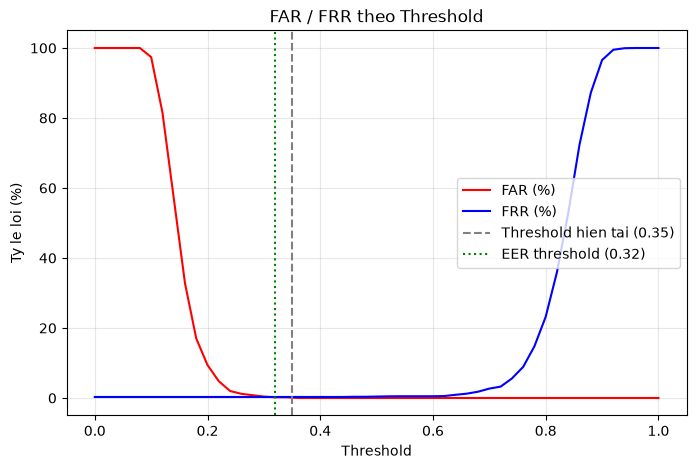

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\far_frr_curve.png


In [8]:
# ===== CELL 7: Ve bieu do FAR / FRR theo threshold =====

plt.figure(figsize=(8, 5))
plt.plot(roc_df['threshold'], roc_df['FAR'] * 100, label='FAR (%)', color='red')
plt.plot(roc_df['threshold'], roc_df['FRR'] * 100, label='FRR (%)', color='blue')
plt.axvline(0.35, color='gray', linestyle='--', label='Threshold hien tai (0.35)')
plt.axvline(eer_row['threshold'], color='green', linestyle=':', label=f"EER threshold ({eer_row['threshold']:.2f})")
plt.xlabel('Threshold')
plt.ylabel('Ty le loi (%)')
plt.title('FAR / FRR theo Threshold')
plt.legend()
plt.grid(alpha=0.3)

plot_path = os.path.join(RESULTS_DIR, 'far_frr_curve.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


Kết quả này rất tốt về mặt con số, và có 1 điểm đáng chú ý đứng sau nó mà tôi muốn bạn thấy trước khi kết luận "xong":
Nhìn vào khoảng cách điểm số: người quen (genuine) đạt 0.70–0.85, người lạ (impostor) chỉ 0.13–0.15. Đây là khoảng trống (gap) rất lớn — gần như không có vùng chồng lấn giữa 2 phân phối. Đó chính là lý do FAR/FRR đều cực thấp (0.2%/0.36%) dù threshold đặt ở đâu trong khoảng 0.2–0.6 cũng sẽ cho kết quả tương tự — hệ thống đang hoạt động trong "vùng dễ".

Vẫn là caveat tôi đã nói ở accuracy 99.6% trước đó, áp dụng y hệt ở đây: LFW là ảnh chụp chuyên nghiệp, đủ sáng, gần chính diện — vừa lợi cho genuine (dễ nhận đúng), vừa lợi cho impostor test (người lạ trong LFW cũng là ảnh "đẹp" nên vẫn tách biệt rõ). Video an ninh thật (webcam, góc nghiêng, thiếu sáng, chuyển động) nhiều khả năng sẽ làm genuine score tụt xuống (gần vùng impostor hơn) chứ khó làm impostor score tăng lên — nên khoảng cách 0.15 vs 0.7-0.85 hiện tại nên được xem là "best case"

Khuyến nghị cụ thể — vì bạn đang dư nhiều khoảng trống, nên tận dụng nó cho mục đích an ninh: hệ thống giám sát nên ưu tiên giảm FAR (chấp nhận nhầm người lạ là người quen) hơn là giảm FRR (từ chối nhầm người quen — chỉ là bất tiện, có thể double-check bằng tay), vì FAR sai là rủi ro an ninh thật sự. Với khoảng cách lớn thế này, bạn có thể nâng threshold cao hơn 0.35 (thay vì chọn đúng điểm EER=0.30, vốn dành cho hệ thống cân bằng, không ưu tiên bên nào) mà gần như không mất gì về FRR

## PHAN B - Danh gia Face Detection tren WIDER FACE

Doc truc tiep tu file da tai thu cong (annotation dang `.txt` goc, khong qua thu vien `datasets`),
theo cau truc:
- Anh: `ai/dataset/benchmarks/wider face/WIDER_val/WIDER_val/images/<event>/<ten_anh>.jpg`
- Annotation: `ai/dataset/benchmarks/wider face/wider_face_annotations/wider_face_split/wider_face_val_bbx_gt.txt`

Neu cau truc thu muc may ban khac, chi can sua 3 bien `WIDER_FACE_DIR` / `WIDER_VAL_IMAGES_DIR` /
`WIDER_VAL_ANNOTATION_PATH` o Cell 8.

**Danh gia don gian hoa** (khong phai toolkit chinh thuc cua WIDER FACE voi PR-curve theo
tung event category) - tinh Precision/Recall/F1 @ IoU>=0.5 tren toan bo anh, VA **recall
theo kich thuoc mat** (small/medium/large) - day moi la con so chung minh dung cai da chot:
detector co bat duoc mat nho/o xa trong dam dong hay khong.

In [9]:
# ===== CELL 8: Doc annotation WIDER FACE tu file .txt local (khong qua thu vien datasets) =====

WIDER_FACE_DIR = os.path.join(BENCHMARK_DIR, 'wider face')
WIDER_VAL_IMAGES_DIR = os.path.join(WIDER_FACE_DIR, 'WIDER_val', 'images')
WIDER_VAL_ANNOTATION_PATH = os.path.join(
    WIDER_FACE_DIR, 'wider_face_annotations', 'wider_face_split', 'wider_face_val_bbx_gt.txt'
)

WIDER_FACE_AVAILABLE = os.path.exists(WIDER_VAL_IMAGES_DIR) and os.path.exists(WIDER_VAL_ANNOTATION_PATH)

if not WIDER_FACE_AVAILABLE:
    print("Khong tim thay du lieu WIDER FACE tai:")
    print(f"  Anh:        {WIDER_VAL_IMAGES_DIR}  (ton tai: {os.path.exists(WIDER_VAL_IMAGES_DIR)})")
    print(f"  Annotation: {WIDER_VAL_ANNOTATION_PATH}  (ton tai: {os.path.exists(WIDER_VAL_ANNOTATION_PATH)})")
    print("Sua lai 3 bien WIDER_FACE_DIR / WIDER_VAL_IMAGES_DIR / WIDER_VAL_ANNOTATION_PATH cho khop may ban.")
    print("PHAN B se duoc bo qua cho lan chay nay.")
else:
    def parse_wider_face_annotations(annotation_path):
        """Doc file wider_face_val_bbx_gt.txt theo dinh dang goc:
        <duong_dan_anh>
        <so_luong_mat>
        <x> <y> <w> <h> <blur> <expr> <illum> <invalid> <occlusion> <pose>
        ...
        Luu y: khi so_luong_mat = 0, file van co 1 dong placeholder (dac diem cua dinh dang goc).
        """
        with open(annotation_path, 'r') as f:
            lines = [line.strip() for line in f.readlines() if line.strip() != '']

        annotations = {}
        i = 0
        while i < len(lines):
            img_path = lines[i]
            i += 1
            if i >= len(lines):
                break
            num_faces = int(lines[i])
            i += 1

            boxes = []
            n_lines_to_read = max(num_faces, 1)
            for _ in range(n_lines_to_read):
                if i >= len(lines):
                    break
                parts = lines[i].split()
                i += 1
                if num_faces == 0:
                    continue  # dong placeholder, khong phai mat that
                x, y, w, h = map(int, parts[0:4])
                invalid = int(parts[7]) if len(parts) > 7 else 0
                boxes.append({'bbox': [x, y, w, h], 'invalid': invalid})

            annotations[img_path] = boxes
        return annotations

    wider_annotations = parse_wider_face_annotations(WIDER_VAL_ANNOTATION_PATH)
    print(f"Da doc annotation: {len(wider_annotations)} anh")

    sample_key = next(iter(wider_annotations))
    print(f"\nVi du: {sample_key} -> {len(wider_annotations[sample_key])} khuon mat")
    print(wider_annotations[sample_key][:2])

    sample_img_path = os.path.join(WIDER_VAL_IMAGES_DIR, sample_key)
    print(f"\nKiem tra doc thu anh mau: {sample_img_path}")
    print("Doc anh thanh cong:", cv2.imread(sample_img_path) is not None)


Da doc annotation: 3226 anh

Vi du: 0--Parade/0_Parade_marchingband_1_465.jpg -> 126 khuon mat
[{'bbox': [345, 211, 4, 4], 'invalid': 0}, {'bbox': [331, 126, 3, 3], 'invalid': 1}]

Kiem tra doc thu anh mau: D:\face-security-system\ai\dataset\benchmarks\wider face\WIDER_val\images\0--Parade/0_Parade_marchingband_1_465.jpg
Doc anh thanh cong: True


In [10]:
# ===== CELL 9: Ham tinh IoU (dinh dang x,y,width,height - kieu COCO) =====

def iou_xywh(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_w, inter_h = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def to_bgr_array(pil_img):
    return cv2.cvtColor(np.array(pil_img.convert('RGB')), cv2.COLOR_RGB2BGR)

print("Da dinh nghia iou_xywh() va to_bgr_array()")


Da dinh nghia iou_xywh() va to_bgr_array()


In [11]:
# ===== CELL 10: Chay danh gia detection tren N anh dau cua WIDER FACE validation =====

N_EVAL_IMAGES = 200  # tang len neu muon danh gia day du hon (~3200 anh validation - se rat lau tren CPU)
IOU_THRESHOLD = 0.5

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang (xem Cell 8)")
else:
    image_level_rows = []
    box_level_rows = []

    image_keys = list(wider_annotations.keys())[:N_EVAL_IMAGES]
    n_images = len(image_keys)

    for idx, img_rel_path in enumerate(image_keys):
        img_full_path = os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path)
        img_bgr = cv2.imread(img_full_path)

        if img_bgr is None:
            print(f"Khong doc duoc anh: {img_full_path} - bo qua")
            continue

        gt_boxes = [b['bbox'] for b in wider_annotations[img_rel_path] if b['invalid'] == 0]

        faces = face_app.get(img_bgr)  # KHONG padding - anh WIDER FACE da la ty le tu nhien
        pred_boxes = [[f.bbox[0], f.bbox[1], f.bbox[2] - f.bbox[0], f.bbox[3] - f.bbox[1]] for f in faces]

        matched_gt = set()
        tp = 0
        for pb in pred_boxes:
            best_iou, best_gt_idx = 0, -1
            for gi, gb in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                iou = iou_xywh(pb, gb)
                if iou > best_iou:
                    best_iou, best_gt_idx = iou, gi
            if best_iou >= IOU_THRESHOLD:
                tp += 1
                matched_gt.add(best_gt_idx)

        fp = len(pred_boxes) - tp
        fn = len(gt_boxes) - len(matched_gt)
        image_level_rows.append([img_rel_path, len(gt_boxes), len(pred_boxes), tp, fp, fn])

        for gi, gb in enumerate(gt_boxes):
            size_px = (gb[2] * gb[3]) ** 0.5
            bucket = 'small(<32px)' if size_px < 32 else ('medium(32-96px)' if size_px < 96 else 'large(>96px)')
            box_level_rows.append([bucket, gi in matched_gt])

        if (idx + 1) % 50 == 0:
            print(f"Da xu ly {idx + 1}/{n_images} anh...")

    img_df = pd.DataFrame(image_level_rows, columns=['image_path', 'n_gt', 'n_pred', 'tp', 'fp', 'fn'])
    total_tp, total_fp, total_fn = img_df['tp'].sum(), img_df['fp'].sum(), img_df['fn'].sum()
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    print(f"\nWIDER FACE validation ({n_images} anh dau) @ IoU>=0.5:")
    print(f"Precision: {precision*100:.1f}%   Recall: {recall*100:.1f}%   F1: {f1*100:.1f}%")

    box_df = pd.DataFrame(box_level_rows, columns=['size_bucket', 'matched'])
    recall_by_size = box_df.groupby('size_bucket')['matched'].mean() * 100
    print("\nRecall theo kich thuoc mat (chung minh kha nang bat mat nho/o xa):")
    print(recall_by_size)

    img_df.to_csv(os.path.join(RESULTS_DIR, 'wider_face_image_level.csv'), index=False)
    box_df.to_csv(os.path.join(RESULTS_DIR, 'wider_face_box_level.csv'), index=False)
    print(f"\nDa luu ket qua chi tiet vao {RESULTS_DIR}")


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Da xu ly 50/200 anh...
Da xu ly 100/200 anh...
Da xu ly 150/200 anh...
Da xu ly 200/200 anh...

WIDER FACE validation (200 anh dau) @ IoU>=0.5:
Precision: 79.7%   Recall: 61.4%   F1: 69.3%

Recall theo kich thuoc mat (chung minh kha nang bat mat nho/o xa):
size_bucket
large(>96px)       99.107143
medium(32-96px)    93.848168
small(<32px)       55.747573
Name: matched, dtype: float64

Da luu ket qua chi tiet vao D:\face-security-system\ai\dataset\evaluation_results


## PHAN C - Danh gia Tracking tren MOT17

**Can tai thu cong** (khong co API tu dong dang tin cay cho MOT17):
1. Vao https://motchallenge.net/data/MOT17/ , tai file zip (co the chi tai 1 phan neu file qua lon)
2. Giai nen, dat 1 sequence (vi du `MOT17-02-FRCNN`) vao:
   `ai/data/benchmarks/mot17/train/MOT17-02-FRCNN/` (ben trong co 2 thu muc con: `img1/` va `gt/gt.txt`)

**De y thoi gian**: MOT17 kha nang (~5GB toan bo train set) - **chi can 1 sequence** la du de
co so lieu cho bao cao, khong can tai het.

In [12]:
# ===== CELL 11: Tai lai YOLOv8 (GPU) =====
from ultralytics import YOLO

person_model = YOLO("yolov8n.pt")
print("Da tai YOLOv8n")

# Neu ultralytics version ho tro .to(), ep model sang GPU
try:
    person_model.to("cuda:0")
    print("YOLO model da duoc chuyen sang cuda:0")
except Exception as e:
    print(f"Khong goi duoc person_model.to('cuda:0'): {e}")


Da tai YOLOv8n
YOLO model da duoc chuyen sang cuda:0


In [13]:
# ===== CELL 12: Kiem tra du lieu MOT17 & dung anh sequence thanh video tam =====

MOT_SEQUENCE = 'MOT17-02-FRCNN'  # doi ten neu muon test sequence khac
mot_seq_dir = os.path.join(BENCHMARK_DIR, MOT_SEQUENCE)
img_dir = os.path.join(mot_seq_dir, 'img1')
gt_path = os.path.join(mot_seq_dir, 'gt', 'gt.txt')

MOT17_AVAILABLE = os.path.exists(img_dir) and os.path.exists(gt_path)

if not MOT17_AVAILABLE:
    print(f"Chua thay du lieu MOT17 tai {mot_seq_dir}")
    print("Tai tu: https://motchallenge.net/data/MOT17/")
    print(f"Giai nen va dat vao: {mot_seq_dir} (co 2 thu muc con: img1/ va gt/)")
    print("PHAN C se duoc bo qua cho lan chay nay.")
else:
    def build_video_from_image_sequence(image_dir, output_video_path, fps=25):
        frame_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png')))
        assert frame_files, f"Khong tim thay anh nao trong {image_dir}"

        first_img = cv2.imread(os.path.join(image_dir, frame_files[0]))
        h, w = first_img.shape[:2]

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))
        for fname in frame_files:
            writer.write(cv2.imread(os.path.join(image_dir, fname)))
        writer.release()
        return len(frame_files), w, h

    temp_video_path = os.path.join(RESULTS_DIR, f'{MOT_SEQUENCE}_temp.mp4')
    n_frames, seq_w, seq_h = build_video_from_image_sequence(img_dir, temp_video_path, fps=25)
    print(f"Da dung {n_frames} anh ({seq_w}x{seq_h}) thanh video tam: {temp_video_path}")


Da dung 600 anh (1920x1080) thanh video tam: D:\face-security-system\ai\dataset\evaluation_results\MOT17-02-FRCNN_temp.mp4


In [14]:
# ===== CELL 13: Chay YOLOv8 + ByteTrack tren video tam, thu thap ket qua tracking =====

if not MOT17_AVAILABLE:
    print("Bo qua Cell nay - chua co du lieu MOT17 (xem Cell 12)")
else:
    mot_track_rows = []

    results_gen = person_model.track(
        source=temp_video_path,
        persist=True,
        tracker="bytetrack.yaml",
        classes=[0],
        conf=0.3,
        stream=True,
        verbose=False,
        device=0,   # ep GPU
    )

    for frame_idx, r in enumerate(results_gen, start=1):  # MOT dung frame index bat dau tu 1
        boxes = r.boxes
        if boxes is not None and len(boxes) > 0 and boxes.id is not None:
            xyxy = boxes.xyxy.cpu().numpy()
            track_ids = boxes.id.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), tid in zip(xyxy, track_ids):
                mot_track_rows.append([frame_idx, int(tid), x1, y1, x2 - x1, y2 - y1])

    track_df = pd.DataFrame(mot_track_rows, columns=["frame", "id", "x", "y", "w", "h"])
    print(f"Tracking hoan tat: {len(track_df)} detections qua {track_df['frame'].nunique()} frame")


Tracking hoan tat: 4781 detections qua 600 frame


In [15]:
# ===== CELL 14: Doc ground truth MOT17 & tinh MOTA/IDF1 bang motmetrics =====

if not MOT17_AVAILABLE:
    print("Bo qua Cell nay - chua co du lieu MOT17 (xem Cell 12)")
else:
    if not hasattr(np, 'asfarray'):
        def _np_asfarray(a, dtype=float, order='K'):
            return np.asarray(a, dtype=dtype, order=order)
        np.asfarray = _np_asfarray

    import motmetrics as mm

    gt_cols = ['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'cls', 'vis']
    gt_df = pd.read_csv(gt_path, header=None, names=gt_cols)
    # Chi giu box duoc danh dau "xet danh gia" (conf==1) va la nguoi di bo (cls==1)
    # Day la don gian hoa - TrackEval chinh thuc co xu ly them cac class distractor khac
    gt_df = gt_df[(gt_df['conf'] == 1) & (gt_df['cls'] == 1)]
    print(f"Ground truth (sau loc): {len(gt_df)} box qua {gt_df['frame'].nunique()} frame")

    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt_df['frame'].unique().tolist()) | set(track_df['frame'].unique().tolist()))

    for frame in all_frames:
        gt_frame = gt_df[gt_df['frame'] == frame]
        tr_frame = track_df[track_df['frame'] == frame]

        gt_ids = gt_frame['id'].tolist()
        tr_ids = tr_frame['id'].tolist()
        gt_boxes = gt_frame[['x', 'y', 'w', 'h']].values
        tr_boxes = tr_frame[['x', 'y', 'w', 'h']].values

        dists = mm.distances.iou_matrix(gt_boxes, tr_boxes, max_iou=0.5)
        acc.update(gt_ids, tr_ids, dists, frameid=frame)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1', 'num_switches',
                 'num_false_positives', 'num_misses', 'num_matches'],
        name=MOT_SEQUENCE,
    )

    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

    metrics_csv_path = os.path.join(RESULTS_DIR, f'mot17_{MOT_SEQUENCE}_metrics.csv')
    summary.to_csv(metrics_csv_path)
    print(f"\nDa luu ket qua tai: {metrics_csv_path}")


Ground truth (sau loc): 18581 box qua 600 frame
               num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
MOT17-02-FRCNN        600 16.4% 0.191 26.2%  38 849 14649        3894

Da luu ket qua tai: D:\face-security-system\ai\dataset\evaluation_results\mot17_MOT17-02-FRCNN_metrics.csv


## Tong ket Notebook 04

Ket qua luu trong `ai/data/evaluation_results/`:
- `far_frr_by_threshold.csv`, `far_frr_curve.png` - duong cong FAR/FRR + EER (Phan A)
- `wider_face_image_level.csv`, `wider_face_box_level.csv` - Precision/Recall/F1 + recall theo kich thuoc mat (Phan B, neu co chay)
- `mot17_<sequence>_metrics.csv` - MOTA/IDF1/ID switches (Phan C, neu co chay)

**Cac so nay dua thang vao Chuong 4 bao cao:**
- FAR/FRR/EER -> tra loi cau hoi "threshold 0.35 co hop ly khong" bang so lieu thay vi doan
- Recall theo kich thuoc mat tren WIDER FACE -> bang chung dinh luong cho claim kien truc da chot
  (YOLOv8 phat hien nguoi + RetinaFace/insightface tren crop de bat mat nho/o xa)
- MOTA/IDF1 tren MOT17 -> danh gia rieng phan ByteTrack, tach biet khoi loi nhan dang khuon mat

**Luu y khi trich dan trong bao cao:** day la ban danh gia don gian hoa (khong phai toolkit
chinh thuc WIDER FACE / TrackEval) - nen ghi ro trong bao cao la "danh gia noi bo theo phuong
phap don gian hoa", tranh so sanh truc tiep con so nay voi bang xep hang chinh thuc cua 2
benchmark tren.